# Feature Engineering and Encoding

In [1]:
import pandas as pd
from category_encoders import TargetEncoder

# Load cleaned datasets
train_df = pd.read_csv('/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/cleaning_train_data.csv')
test_df = pd.read_csv('/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/cleaning_test_data.csv')
holdout_df = pd.read_csv('/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/cleaning_holdout_data.csv')

# Print date ranges for verification
print("Train Date Range:", train_df['date'].min(), "to", train_df['date'].max())
print("Test Date Range:", test_df['date'].min(), "to", test_df['date'].max())
print("Holdout Date Range:", holdout_df['date'].min(), "to", holdout_df['date'].max())

# Ensure datetime format
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])
holdout_df['date'] = pd.to_datetime(holdout_df['date'])

Train Date Range: 2012-03-31 to 2019-12-31
Test Date Range: 2020-01-31 to 2021-12-31
Holdout Date Range: 2022-01-31 to 2023-12-31


In [2]:
# Funtion to add date features
def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add separate date features to the dataframe from the 'date' column. 
    Features added: year, month, quarter
    """
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter

    df.insert(1, 'year', df.pop('year'))
    df.insert(2, 'month', df.pop('month'))
    df.insert(3, 'quarter', df.pop('quarter'))

    return df

# Apply date feature addition
train_df = add_date_features(train_df)
test_df = add_date_features(test_df)
holdout_df = add_date_features(holdout_df)

In [3]:
# See all columns and first few rows
pd.set_option('display.max_columns', None)

In [4]:
# Train set preview
print(train_df.shape)
train_df.head(1)

(576815, 43)


,date,year,month,quarter,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2012-03-31,2012,3,1,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,ATL,30002,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,"Atlanta-Sandy Springs-Roswell, GA",33.7338,-84.3922


In [5]:
# Test set preview
print(test_df.shape)
test_df.head(1)

(148448, 43)


,date,year,month,quarter,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2020-01-31,2020,1,1,184000.0,168450.0,123.333333,109.8998,35.0,30.0,34.0,37.0,50.0,0.954732,0.171429,0.3,CHI,60482,3.0,0.0,2.0,0.0,68.0,30.0,60.0,5.0,14.0,10849.0,42.1,27037.0,10795.0,4598.0,964.0,169000.0,5690.0,414.0,10573.0,10573.0,5089.0,164839.734849,"Chicago-Naperville-Elgin, IL-IN",41.6675,-87.9597


In [6]:
# Holdout set preview
print(holdout_df.shape)
holdout_df.head(1)

(148943, 43)


,date,year,month,quarter,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2022-01-31,2022,1,1,340000.0,349999.0,189.867865,195.526649,282.0,287.0,241.0,73.0,12.0,0.991177,0.308511,0.634146,ORL,32771,9.0,0.0,1.0,1.0,56.0,64.0,18.0,4.0,9.0,57074.0,37.7,33896.0,56681.0,22246.0,1289.0,261800.0,29485.0,1469.0,55621.0,55621.0,24381.0,314667.746005,"Orlando-Kissimmee-Sanford, FL",28.4343,-81.363


Encoders will only be fit on the training set to avoid data leakage. Then, they are going to be applied to test and holdout data.

## Frequency Encoding for Zipcode

In [9]:
zip_counts = train_df['zipcode'].value_counts()

# Map the dataset entries to their zip code counts
train_df['zipcode_freq'] = train_df['zipcode'].map(zip_counts)
test_df['zipcode_freq'] = test_df['zipcode'].map(zip_counts).fillna(0)
holdout_df['zipcode_freq'] = holdout_df['zipcode'].map(zip_counts).fillna(0)

# Display the first few entries
print("Zipcode frequency on Train Set:")
print(train_df[['zipcode', 'zipcode_freq']].head())

Zipcode frequency on Train Set:
   zipcode  zipcode_freq
0    30002            94
1    15469            86
2    15464            85
3     2739            94
4    15461            94


## Target Encoding for the city

In [10]:
target_encoder = TargetEncoder(cols=['city_full'])

train_df['city_encoded'] = target_encoder.fit_transform(train_df['city_full'], train_df['price'])
test_df['city_encoded'] = target_encoder.transform(test_df['city_full'])
holdout_df['city_encoded'] = target_encoder.transform(holdout_df['city_full'])

print("City encoding on Train Set:")
print(train_df[['city_full', 'city_encoded']].head())

City encoding on Train Set:
                           city_full   city_encoded
0  Atlanta-Sandy Springs-Roswell, GA  192627.058387
1                     Pittsburgh, PA  131828.753854
2                     Pittsburgh, PA  131828.753854
3     Boston-Cambridge-Newton, MA-NH  472075.429542
4                     Pittsburgh, PA  131828.753854


In [11]:
# Preview the training set after encoding the city
train_df.head(1)

,date,year,month,quarter,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng,zipcode_freq,city_encoded
0,2012-03-31,2012,3,1,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,ATL,30002,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,"Atlanta-Sandy Springs-Roswell, GA",33.7338,-84.3922,94,192627.058387


We will drop the `median_sale_price` column, since that contains information about price and will contribute to data leakage. Also, we will drop columns we know are redundant, these will include: `date`, `city`, `city_full`, and `zipcode`.

In [12]:
# Drop columns 
columns = ['date', 'city_full', 'city', 'zipcode', 'median_sale_price']
train_df.drop(columns=columns, inplace=True)
test_df.drop(columns=columns, inplace=True)
holdout_df.drop(columns=columns, inplace=True)

In [13]:
print(train_df.shape)
train_df.head(1)

(576815, 40)


,year,month,quarter,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,lat,lng,zipcode_freq,city_encoded
0,2012,3,1,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,33.7338,-84.3922,94,192627.058387


For the rest of features, we will use a Filter feature engineering method. Specifically, we will use Mutual Information Regression. This choice ensures we capture non-linear effects and will help us keep features that are most relevant to the target variable. 

## Mutual Information Regression

In [14]:
from sklearn.feature_selection import mutual_info_regression

# Get the feature matrix and target vector
X = train_df.drop(columns=['price'])
y = train_df['price']

# Calculate mutual information
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Mutual Information Scores:")
print(mi_scores)

Mutual Information Scores:
median_list_price               1.553236
Median Home Value               1.392794
median_list_ppsf                0.995580
median_ppsf                     0.969008
Per Capita Income               0.860238
Median Rent                     0.794697
Total Housing Units             0.555938
Total School Enrollment         0.555328
Total School Age Population     0.555319
Total Population                0.554835
Total Families Below Poverty    0.553608
Total Labor Force               0.547792
Median Commute Time             0.542704
Unemployed Population           0.480465
lat                             0.417993
lng                             0.417626
city_encoded                    0.417560
Median Age                      0.283279
school                          0.229247
park                            0.220289
restaurant                      0.180654
avg_sale_to_list                0.165484
bank                            0.152892
station                       

Also, we will consider VIF to determine multicolinearity. This will help us identify which varibles are redundant.

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Function to calculate VIF
def calculate_vif(df: pd.DataFrame, target_col=None) -> pd.DataFrame:
    """
    Calculate Variance Inflation Factor (VIF) for each feature in the dataframe.
    If target_col is provided, it will be excluded from the VIF calculation.
    """
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include=['float64', 'int64']).copy()

    # Drop target column if specified
    if target_col and target_col in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=[target_col])

    # Add constant for intercept
    X = add_constant(numeric_df)

    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data['feature'] = numeric_df.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i + 1) for i in range(len(numeric_df.columns))]

    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)



In [17]:
# Look at VIF scores and correlation with the original training set
df = pd.read_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/raw/train_data.csv")
vif_scores = calculate_vif(df, target_col='price')
print("VIF Scores:")
print(vif_scores)

/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/.venv/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


VIF Scores:
                         feature          VIF
0        Total School Enrollment          inf
1    Total School Age Population          inf
2               Total Population  6600.440350
3              Total Labor Force   839.557009
4            Median Commute Time   650.528668
5   Total Families Below Poverty   573.705680
6            Total Housing Units    21.298479
7                   new_listings    19.930888
8                     homes_sold    13.409262
9          Unemployed Population    12.881559
10                    restaurant    10.915101
11                          bank    10.680631
12                   supermarket     9.630326
13                 pending_sales     9.241440
14             Median Home Value     6.826955
15                     inventory     5.887100
16                          park     5.676253
17                        school     5.657422
18                       station     4.654858
19             Per Capita Income     4.619926
20                   M

- VIF > 10 will show serious multicolinearity 
- VIF > 100 will require dropping/re-engineering 
- VIF = INF is perfect linear redundancy and will require dropping

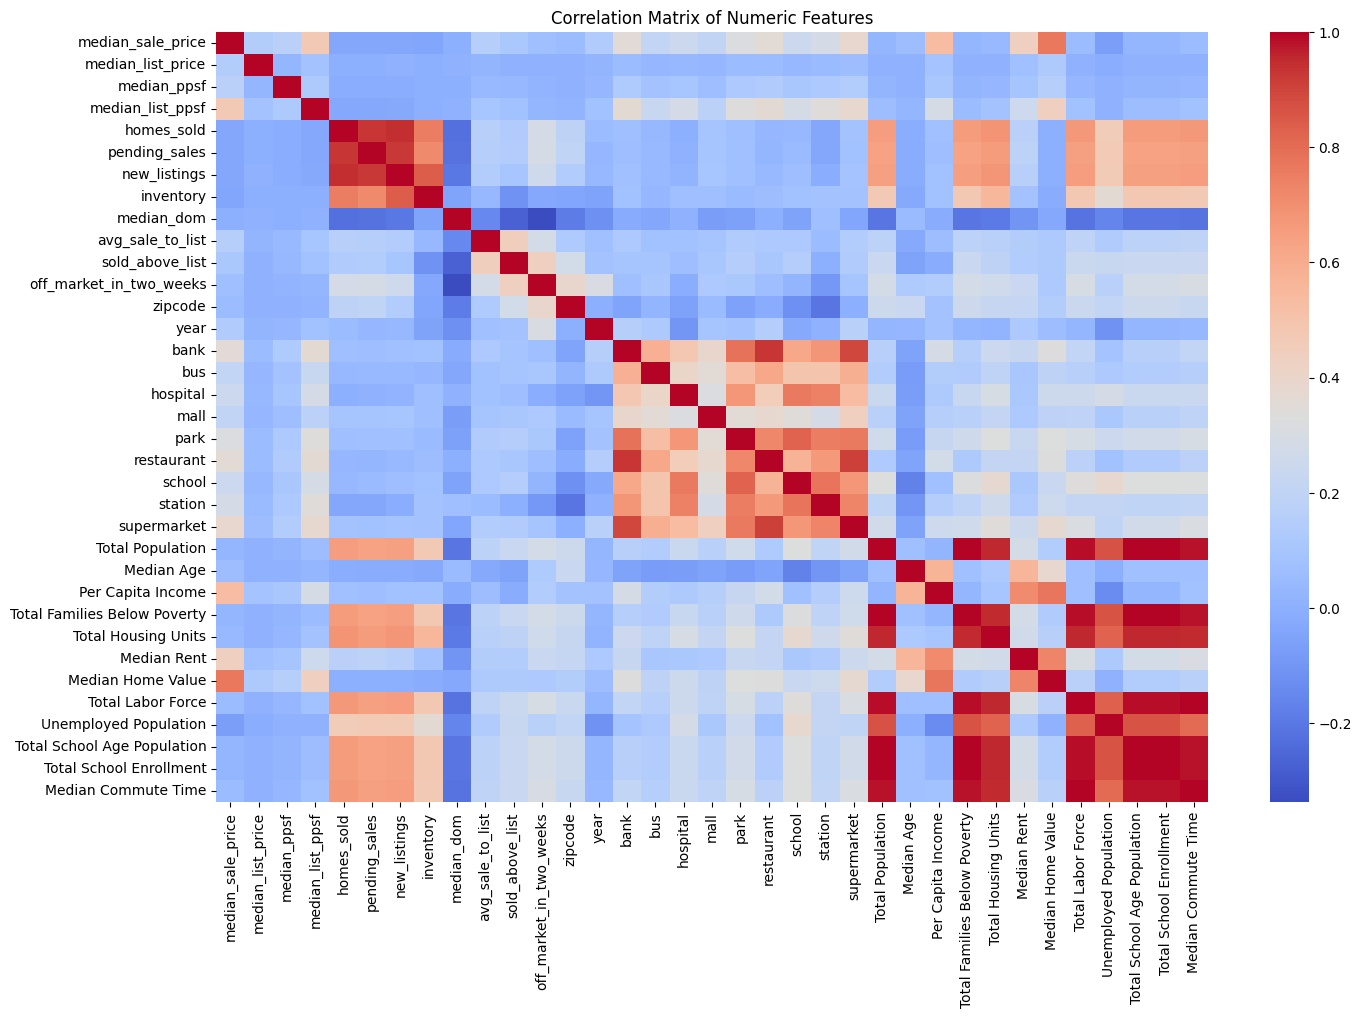

In [19]:
# Correlation matrix of numeric features

import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['price'], errors='ignore')

corr_matrix = numeric_cols.corr()

# Display the full matrix as a heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False,
)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [20]:
# Compute correlation with target variable 'price'
correlation_with_price = numeric_cols.corrwith(df['price']).sort_values(ascending=False)
print("Correlation with Price:")
print(correlation_with_price)

Correlation with Price:
median_sale_price               0.917557
Median Home Value               0.815759
Per Capita Income               0.586481
median_list_ppsf                0.499372
Median Rent                     0.467280
supermarket                     0.414520
restaurant                      0.389496
bank                            0.389124
park                            0.337198
station                         0.302174
school                          0.249658
hospital                        0.246418
bus                             0.221153
mall                            0.212890
median_ppsf                     0.175214
year                            0.151639
median_list_price               0.150757
avg_sale_to_list                0.117006
sold_above_list                 0.108256
Median Age                      0.056892
off_market_in_two_weeks         0.053252
Total Labor Force               0.042292
Median Commute Time             0.042274
zipcode                         0

In [21]:
# Save the cleaned datasets
train_df.to_csv('/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/feature_engineered_train_data.csv', index=False)
test_df.to_csv('/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/feature_engineered_test_data.csv', index=False)
holdout_df.to_csv('/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/feature_engineered_holdout_data.csv', index=False)

print("Feature engineered datasets saved successfully.")
print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
print("Holdout set shape:", holdout_df.shape)

Feature engineered datasets saved successfully.
Train set shape: (576815, 40)
Test set shape: (148448, 40)
Holdout set shape: (148943, 40)
